<a href="https://colab.research.google.com/github/BADIAMOHAMEDAYMANE/News-Classification-Project/blob/main/News_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1-Installation & imports

In [9]:
# ============================================================
# BLOC 1 : Installation & imports
# ============================================================
!pip install tensorflow scikit-learn nltk matplotlib seaborn -q

import pandas as pd
import numpy as np
import re, string, pickle
import nltk
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

print("✓ Librairies chargées")

✓ Librairies chargées


# 2-Chargement & équilibrage des données

In [11]:
# ============================================================
# BLOC 2 : Chargement & équilibrage
# ============================================================
from google.colab import files
uploaded = files.upload()
import io

filename = list(uploaded.keys())[0]

# Tentative lecture JSON lines puis JSON classique
try:
    df = pd.read_json(io.BytesIO(uploaded[filename]), lines=True)
    print("✓ Chargé en format JSON lines")
except:
    df = pd.read_json(io.BytesIO(uploaded[filename]))
    print("✓ Chargé en format JSON classique")

# Vérification des colonnes obligatoires
print(f"✓ Colonnes disponibles : {df.columns.tolist()}")
assert 'category' in df.columns, "❌ Colonne 'category' manquante !"
assert 'headline' in df.columns, "❌ Colonne 'headline' manquante !"

print(f"✓ Articles chargés : {len(df)}")
print(f"✓ Catégories : {df['category'].nunique()}")
print(df['category'].value_counts().head(10))

Saving News_Category_Dataset_v3.json to News_Category_Dataset_v3 (2).json
✓ Chargé en format JSON lines
✓ Colonnes disponibles : ['link', 'headline', 'category', 'short_description', 'authors', 'date']
✓ Articles chargés : 209527
✓ Catégories : 42
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64


# 3-Nettoyage du texte

In [13]:
df["text"] = df["headline"].astype(str) + " " + df["short_description"].astype(str)
print(f"✓ Colonne 'text' créée : {df['text'].iloc[0][:80]}...")
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("Nettoyage en cours...")
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 10]

print(f"✓ Articles après nettoyage : {len(df)}")

✓ Colonne 'text' créée : Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters Hea...
Nettoyage en cours...
✓ Articles après nettoyage : 209287


# 4-Tokenisation & encodage

In [14]:
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tokenizer
tokenizer = Tokenizer(num_words=15000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in X_train_seq]
max_len = min(int(np.percentile(lengths, 90)), 150)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

# LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
num_classes = len(le.classes_)

# Poids de classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = dict(enumerate(class_weights))

print(f"✓ max_len = {max_len} | classes = {num_classes}")
print(f"✓ X_train : {X_train_pad.shape} | X_test : {X_test_pad.shape}")
print(f"✓ Classes : {le.classes_}")

✓ max_len = 26 | classes = 42
✓ X_train : (167429, 26) | X_test : (41858, 26)
✓ Classes : ['ARTS' 'ARTS & CULTURE' 'BLACK VOICES' 'BUSINESS' 'COLLEGE' 'COMEDY'
 'CRIME' 'CULTURE & ARTS' 'DIVORCE' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'FIFTY' 'FOOD & DRINK' 'GOOD NEWS' 'GREEN' 'HEALTHY LIVING'
 'HOME & LIVING' 'IMPACT' 'LATINO VOICES' 'MEDIA' 'MONEY' 'PARENTING'
 'PARENTS' 'POLITICS' 'QUEER VOICES' 'RELIGION' 'SCIENCE' 'SPORTS' 'STYLE'
 'STYLE & BEAUTY' 'TASTE' 'TECH' 'THE WORLDPOST' 'TRAVEL' 'U.S. NEWS'
 'WEDDINGS' 'WEIRD NEWS' 'WELLNESS' 'WOMEN' 'WORLD NEWS' 'WORLDPOST']


# 5-Construction & entraînement du modèle

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU détecté : {gpus[0].name}")
else:
    print("⚠️ Aucun GPU — allez dans Runtime > Modifier le type d'exécution > T4 GPU")

# Construction du modèle sur GPU
with tf.device('/GPU:0'):
    model = Sequential([
        Embedding(input_dim=15000, output_dim=128, input_length=max_len),
        Dropout(0.2),
        Bidirectional(LSTM(64, return_sequences=False, dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# Entraînement
with tf.device('/GPU:0'):
    history = model.fit(
        X_train_pad, y_train_enc,
        validation_split=0.2,
        batch_size=128,        # augmenté pour profiter du GPU
        epochs=15,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

# Évaluation
loss, acc = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"\n✅ Accuracy sur le test : {acc*100:.2f}%")
print("✓ Entraînement terminé !")

⚠️ Aucun GPU — allez dans Runtime > Modifier le type d'exécution > T4 GPU


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 181s 162ms/step - accuracy: 0.1749 - loss: 3.1930 - val_accuracy: 0.3050 - val_loss: 2.5610 - learning_rate: 0.0010
Epoch 2/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 175s 167ms/step - accuracy: 0.2820 - loss: 2.5281 - val_accuracy: 0.3777 - val_loss: 2.2500 - learning_rate: 0.0010
Epoch 3/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 160s 153ms/step - accuracy: 0.3441 - loss: 2.2070 - val_accuracy: 0.4106 - val_loss: 2.1218 - learning_rate: 0.0010
Epoch 4/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 158s 151ms/step - accuracy: 0.3834 - loss: 2.0059 - val_accuracy: 0.4159 - val_loss: 2.1219 - learning_rate: 0.0010
Epoch 5/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 156s 149ms/step - accuracy: 0.4122 - loss: 1.8587 - val_accuracy: 0.4255 - val_loss: 2.0970 - learning_rate: 0.0010
Epoch 6/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 154s 148ms/step - accuracy: 0.4340 - loss: 1.7307 - val_accuracy: 0.4440 - val_loss: 2.0847 - learning_rate: 0.0010
Epoch 7/15
1047/1047 ━━━━━━━━━━━━━━━━━━━━ 200s 146ms

# 6-Évaluation & visualisation

Shape prédictions : (41858, 42)
Exemple proba[0]  : [1.05297342e-01 2.80734675e-04 4.64834832e-03 4.60150503e-02
 4.21255715e-02 6.48260210e-03 8.58455198e-04 1.48507790e-03
 5.63735157e-05 1.08723314e-02 5.80864586e-03 1.77849251e-05
 3.06225009e-02 2.55279563e-04 1.86724239e-03 4.36890358e-03
 1.43858306e-02 9.36692140e-06 9.58824232e-02 1.30873325e-03
 9.80546046e-03 1.99052854e-03 9.77874734e-04 9.11419920e-04
 1.49059976e-02 1.33797117e-02 9.93376523e-02 5.36434259e-03
 1.06985467e-02 2.52794032e-03 2.50857993e-04 2.84866168e-04
 1.60877709e-04 2.86391447e-03 1.27808275e-02 7.03148471e-05
 8.50737979e-06 5.45100134e-04 6.03467505e-03 1.23593733e-02
 1.27951789e-03 4.30813074e-01]
Somme proba[0]    : 1.0000
Classe prédite[0] : 41
Classe réelle[0]  : 24
🎯 Accuracy    : 45.38%
🎯 Top-3 Acc   : 68.98%

                precision    recall  f1-score   support

          ARTS      0.197     0.392     0.262       301
ARTS & CULTURE      0.184     0.437     0.259       268
  BLACK VOICES   

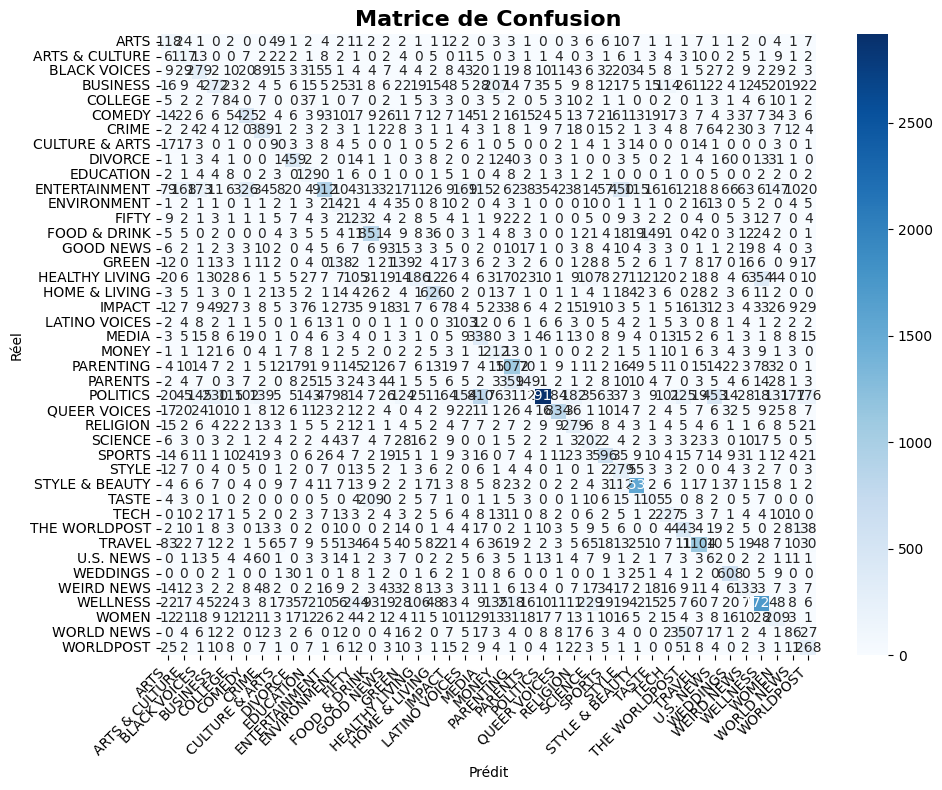

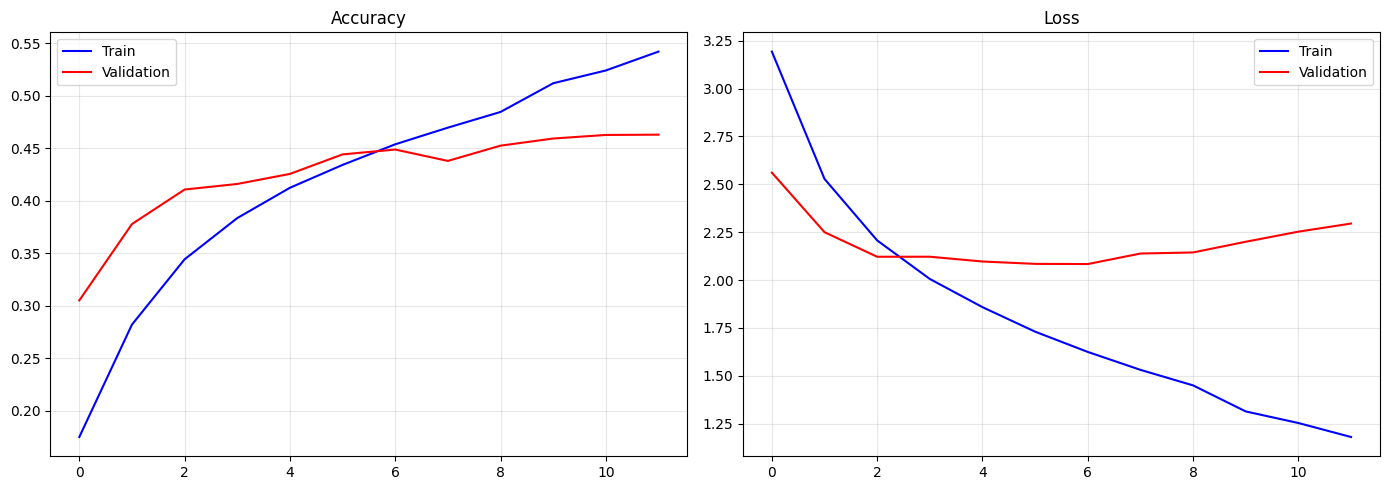

In [17]:
y_pred_proba   = model.predict(X_test_pad, batch_size=128, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1)
print(f"Shape prédictions : {y_pred_proba.shape}")
print(f"Exemple proba[0]  : {y_pred_proba[0]}")
print(f"Somme proba[0]    : {y_pred_proba[0].sum():.4f}")  # doit être ≈ 1.0
print(f"Classe prédite[0] : {y_pred_classes[0]}")
print(f"Classe réelle[0]  : {y_test_enc[0]}")

accuracy = accuracy_score(y_test_enc, y_pred_classes)
top3_accuracy = sum(
    y_test_enc[i] in np.argsort(y_pred_proba[i])[-3:]
    for i in range(len(y_test_enc))
) / len(y_test_enc)

print(f"🎯 Accuracy    : {accuracy*100:.2f}%")
print(f"🎯 Top-3 Acc   : {top3_accuracy*100:.2f}%")
print("\n" + classification_report(y_test_enc, y_pred_classes, target_names=le.classes_, digits=3))

# Matrice de confusion
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight'); plt.show()

# Courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], 'b-', label='Train')
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation')
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-', label='Train')
axes[1].plot(history.history['val_loss'], 'r-', label='Validation')
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight'); plt.show()

# 7-Prédiction & sauvegarde

In [18]:
def predict_category(headline, description):
    text = clean_text(headline + " " + description)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post")
    pred = model.predict(padded, verbose=0)[0]
    top3_idx = np.argsort(pred)[-3:][::-1]

    print(f"\n📰 {headline}")
    for i, idx in enumerate(top3_idx, 1):
        cat  = le.inverse_transform([idx])[0]
        prob = pred[idx]
        bar  = "█" * int(prob * 20)
        print(f"   {i}. {cat:15s} : {prob*100:5.2f}% {bar}")
    return le.inverse_transform([top3_idx[0]])[0]

# Tests
predict_category("Lakers defeat Celtics in NBA Finals", "Historic basketball game ends with dramatic victory")
predict_category("New smartphone released by Apple", "The latest iPhone features advanced AI capabilities")
predict_category("President announces economic reform", "Government unveils comprehensive plan for economic recovery")

# Sauvegarde
model.save('improved_news_classifier.h5')
with open('improved_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
joblib.dump(le, 'improved_label_encoder.pkl')

print("\n✓ Modèle sauvegardé : improved_news_classifier.h5")
print("✓ Tokenizer         : improved_tokenizer.pkl")
print("✓ Label encoder     : improved_label_encoder.pkl")


📰 Lakers defeat Celtics in NBA Finals
   1. SPORTS          : 99.67% ███████████████████
   2. WEIRD NEWS      :  0.27% 
   3. COMEDY          :  0.03% 

📰 New smartphone released by Apple
   1. TECH            : 93.50% ██████████████████
   2. BUSINESS        :  4.98% 
   3. POLITICS        :  0.96% 



📰 President announces economic reform
   1. WORLD NEWS      : 29.55% █████
   2. THE WORLDPOST   : 29.13% █████
   3. BUSINESS        : 15.10% ███

✓ Modèle sauvegardé : improved_news_classifier.h5
✓ Tokenizer         : improved_tokenizer.pkl
✓ Label encoder     : improved_label_encoder.pkl
